## Learning Curve — MIL Gated Attention
### Stratégie : jeux équilibrés croissants (10R+10S → 15R+15S → ... → 53R+53S)
Objectif : montrer qu'on obtient un modèle performant avec un **minimum de données**.

In [1]:
import os, glob, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_recall_curve)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

import sys
print(f"Python : {sys.version}")
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
#if torch.cuda.is_available():
    #print(f"GPU    : {torch.cuda.get_device_name()}")

Python : 3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 01:59:35) [GCC 14.3.0]
Torch  : 2.11.0+cu130
CUDA   : True


In [3]:
# Configuration de hyperparamètres

PT_DIR      = "embeddings_out"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"

SEED       = 42
BATCH_SIZE = 4
EPOCHS     = 1000
LR         = 3e-4
ATTN_DIM   = 32
HIDDEN     = 32
DROPOUT    = 0.1

# Paliers : nombre de génomes PAR CLASSE (S et R)
SIZES     = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45] # 50, 55, 60 : à elever parce que ils vont etre identique au plier 45 !
#N_REPEATS = 4   # répétitions par palier pour stabiliser les résultats

device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f" Config | device : {device}")
print(f"   Paliers (par classe) : {SIZES}")
print(f"   Soit en total génomes : {[2*s for s in SIZES]}")
#print(f"   Répétitions par palier : {N_REPEATS}")

 Config | device : cuda
   Paliers (par classe) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45]
   Soit en total génomes : [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90]


In [4]:
# Chargement des embeddings et labels

def load_pt(fp):
    obj = torch.load(fp, map_location="cpu")
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    return gid, X.float()

def load_labels(path):
    df = pd.read_csv(path, sep="\t", dtype=str)
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))

id_to_y = load_labels(LABELS_PATH)

all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]

all_labels      = np.array([id_to_y[load_pt(fp)[0]] for fp in matched])
resistant_idx   = np.where(all_labels == 1)[0]   # indices dans matched[]
susceptible_idx = np.where(all_labels == 0)[0]

n_R = len(resistant_idx)
n_S = len(susceptible_idx)

_, X0   = load_pt(matched[0])
emb_dim = X0.shape[1]

print(f" Dataset complet :")
print(f"   Total labellisés : {len(matched)}")
print(f"   Résistants  (R)  : {n_R}  ({n_R/len(matched):.1%})")
print(f"   Sensibles   (S)  : {n_S}  ({n_S/len(matched):.1%})")
print(f"   Embedding dim    : {emb_dim}")
print(f"   Palier max       : {min(n_R, n_S)} par classe")

 Dataset complet :
   Total labellisés : 1006
   Résistants  (R)  : 61  (6.1%)
   Sensibles   (S)  : 945  (93.9%)
   Embedding dim    : 480
   Palier max       : 61 par classe


In [5]:
# Définition de Dataset MIL & collate

class GenomeMILDataset(Dataset):
    def __init__(self, file_list, id_to_y):
        self.files   = file_list
        self.id_to_y = id_to_y

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        gid, X = load_pt(self.files[idx])
        y = float(self.id_to_y[gid])
        return X, torch.tensor(y, dtype=torch.float32), gid


def mil_collate(batch):
    xs, ys, gids = zip(*batch)
    D    = xs[0].shape[1]
    Pmax = max(x.shape[0] for x in xs)
    Xpad = torch.zeros((len(xs), Pmax, D))
    mask = torch.zeros((len(xs), Pmax))
    for i, x in enumerate(xs):
        Xpad[i, :x.shape[0]] = x
        mask[i, :x.shape[0]] = 1.0
    return Xpad, mask, torch.stack(list(ys)), list(gids)

In [6]:
# Modèle MIL Gated Attention

class GatedAttentionMIL(nn.Module):
    def __init__(self, emb_dim, attn_dim=32, hidden=32, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.V = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Tanh())
        self.U = nn.Sequential(nn.Linear(emb_dim, attn_dim), nn.Sigmoid())
        self.w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, hidden),
            #nn.BatchNorm1d(hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, X, mask):
        X = self.drop(X)
        A = self.w(self.V(X) * self.U(X)).squeeze(-1)
        A = A.masked_fill(mask == 0, float("-inf"))
        alpha = torch.softmax(A, dim=1)
        z     = torch.sum(X * alpha.unsqueeze(-1), dim=1)
        logit = self.classifier(z).squeeze(-1)
        return logit, alpha


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_y, all_prob = [], []
    for Xpad, mask, y, _ in loader:
        logits, _ = model(Xpad.to(device), mask.to(device))
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_prob)

def find_best_threshold(y_true, y_prob):
    p, r, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2*p*r / (p+r+1e-8)
    return float(thr[np.argmax(f1s)])

def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1":  f1_score(y_true, y_pred, zero_division=0),
        "auc": auc,
    }

n_params = sum(p.numel() for p in
               GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).parameters()
               if p.requires_grad)
print(f" Modèle prêt | emb_dim={emb_dim} | paramètres={n_params:,}")

 Modèle prêt | emb_dim=480 | paramètres=46,306


In [7]:
# Incremental_training (4 folds)

from sklearn.model_selection import StratifiedKFold

set_seed(SEED)
N_FOLDS    = 4
N_TEST_EXT = 15   # R par fold (sauf un fold qui aura 16R)

# Division des 61R en 4 groupes fixes
all_R = resistant_idx.copy()
np.random.shuffle(all_R)

# Groupes de test fixes
fold_test_R = np.array_split(all_R, N_FOLDS)

# ex :
        # fold_test_R[0] = Groupe A (16R)
        # fold_test_R[1] = Groupe B (15R)
        # fold_test_R[2] = Groupe C (15R)
        # fold_test_R[3] = Groupe D (15R)

all_S = susceptible_idx.copy()
np.random.shuffle(all_S)
fold_test_S = np.array_split(all_S, N_FOLDS)

print(f"61R divisés en {N_FOLDS} groupes de test fixes :")
for k, grp in enumerate(fold_test_R):
    print(f"   Groupe {k+1} : {len(grp)}R")
print()

# ex :
        # fold_test_s[0] = Groupe A (214S) : test fold 1, jamais dans train fold 1
        # fold_test_s[1] = Groupe B (214S) : test fold 2, jamais dans train fold 2
        # fold_test_s[2] = Groupe C (213S) : test fold 3, jamais dans train fold 3
        # fold_test_s[3] = Groupe D (213S) : test fold 4, jamais dans train fold 4

lc_results  = []
best_models = {}   # n_per_class : meilleur state_dict (meilleur fold)
all_fold_models = {}

print(f"{'Palier':>14} | {'AUC moy':>8} {'±':>5} | {'F1 moy':>8} {'±':>5} | "
      f"{'AUC f1':>6} {'AUC f2':>6} {'AUC f3':>6} {'AUC f4':>6}")
print("-" * 80)

for n_per_class in SIZES:

    fold_aucs, fold_f1s = [], []
    fold_sens, fold_spec = [], []
    fold_TP, fold_TN      = [], [] 
    fold_FP, fold_FN      = [], []
    fold_thresholds       = [] 
    best_auc_palier     = -1.0
    best_state_palier   = None

    for fold_idx in range(N_FOLDS):

        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)

        # Test : groupe fixe du fold
        te_R = fold_test_R[fold_idx]
        te_S = fold_test_S[fold_idx][:len(te_R)]   # prend len(te_R) S du groupe fixe
        te_files = [matched[i] for i in np.concatenate([te_R, te_S])]

        # Train : R disponibles = tous les R hors test
        pool_R_fold = np.concatenate([
            fold_test_R[k] for k in range(N_FOLDS) if k != fold_idx])
        
        # pool_R_fold = les R des 3 autres groupes
        # ex : fold 1 → pool = Groupe B+C+D = 40R
        
        # Pool S — tous les S des 3 autres groupes
        pool_S_fold = np.concatenate([
            fold_test_S[k] for k in range(N_FOLDS) if k != fold_idx])

        # On pioche n_per_class R parmi le pool disponible
        n_train_R = min(n_per_class, len(pool_R_fold))
        sel_R = np.random.choice(pool_R_fold, size=n_train_R, replace=False)
        sel_S = np.random.choice(pool_S_fold, size=n_train_R, replace=False)

        tr_files  = [matched[i] for i in np.concatenate([sel_R, sel_S])]
        tr_labels = np.array([id_to_y[load_pt(f)[0]] for f in tr_files])

        # DataLoaders
        tr_ds = GenomeMILDataset(tr_files, id_to_y)
        te_ds = GenomeMILDataset(te_files, id_to_y)

        class_counts   = np.bincount(tr_labels)
        sample_weights = 1.0 / class_counts[tr_labels]
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(tr_labels), replacement=True
        )
        bs = max(2, min(BATCH_SIZE, n_train_R // 2))

        tr_loader = DataLoader(tr_ds, batch_size=bs, sampler=sampler,
                               collate_fn=mil_collate)
        te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False,
                               collate_fn=mil_collate)

        # Entraînement avec plateau stopping
        model     = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

        best_loss  = float("inf")
        no_improve = 0
        PATIENCE   = 10

        for epoch in range(1, EPOCHS + 1):
            model.train()
            epoch_loss, n_batches = 0.0, 0
            for Xpad, mask, y, _ in tr_loader:
                Xpad, mask, y = Xpad.to(device), mask.to(device), y.to(device)
                optimizer.zero_grad()
                logits, _ = model(Xpad, mask)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

            train_loss = epoch_loss / n_batches
            if train_loss < best_loss - 1e-4:
                best_loss  = train_loss
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= PATIENCE:
                    break

        # Évaluation
        test_y, test_prob = get_probs(model, te_loader)
        
        best_thr = find_best_threshold(test_y, test_prob) \
                   if len(np.unique(test_y)) > 1 else 0.5
        
        m = compute_metrics(test_y, test_prob, threshold=best_thr)

        auc_fold = m["auc"] or 0.0
        f1_fold  = m["f1"]
        
        # Sensibilité et Spécificité
        y_pred = (test_prob >= best_thr).astype(int)
        TP = int(((y_pred == 1) & (test_y == 1)).sum())
        TN = int(((y_pred == 0) & (test_y == 0)).sum())
        FP = int(((y_pred == 1) & (test_y == 0)).sum())
        FN = int(((y_pred == 0) & (test_y == 1)).sum())

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # recall R
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # recall S

        fold_aucs.append(auc_fold)
        fold_f1s.append(f1_fold)
        fold_sens.append(sensitivity)
        fold_spec.append(specificity)
        
        fold_TP.append(TP)
        fold_TN.append(TN)  
        fold_FP.append(FP)  
        fold_FN.append(FN) 
        
        fold_thresholds.append(best_thr)
        
        if n_per_class not in all_fold_models:
            all_fold_models[n_per_class] = {}
        all_fold_models[n_per_class][fold_idx] = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        # Garde le meilleur modèle en mémoire 
        if auc_fold > best_auc_palier:
            best_auc_palier   = auc_fold
            best_state_palier = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    # Stocke le meilleur modèle du palier
    best_models[n_per_class] = best_state_palier
    best_fold = int(np.argmax(fold_aucs)) + 1

    lc_results.append({
        "n_per_class": n_per_class,
        "n_total":     2 * n_per_class,
        "auc_mean":    np.mean(fold_aucs),
        "auc_std":     np.std(fold_aucs),
        "f1_mean":     np.mean(fold_f1s),
        "f1_std":      np.std(fold_f1s),
        "sens_mean":   np.mean(fold_sens),
        "sens_std":    np.std(fold_sens),   
        "spec_mean":   np.mean(fold_spec),  
        "spec_std":    np.std(fold_spec),
        "thr_mean":    np.mean(fold_thresholds), #seuil moyen
        "fold_aucs":   fold_aucs,
        "fold_f1s":    fold_f1s,
        "fold_sens":   fold_sens,           
        "fold_spec":   fold_spec,            
        "best_fold":   best_fold,
        "fold_TP":     fold_TP,   
        "fold_TN":     fold_TN,   
        "fold_FP":     fold_FP,   
        "fold_FN":     fold_FN, 
        "fold_thresholds":  fold_thresholds,    #seuils par fold
    })

    print(
        f"  {n_per_class:3d}R+{n_per_class:3d}S = {2*n_per_class:3d} | "
        f"{np.mean(fold_aucs):8.3f} {np.std(fold_aucs):5.3f} | "
        f"{np.mean(fold_f1s):8.3f} {np.std(fold_f1s):5.3f} | "
        f"{fold_aucs[0]:6.3f} {fold_aucs[1]:6.3f} "
        f"{fold_aucs[2]:6.3f} {fold_aucs[3]:6.3f} "
        f"(best=fold{best_fold} | thr={np.mean(fold_thresholds):.2f})"
    )


print("\n Learning Curve terminée !")
print(f"   Modèles en mémoire : best_models[n] pour n dans {list(best_models.keys())}")

61R divisés en 4 groupes de test fixes :
   Groupe 1 : 16R
   Groupe 2 : 15R
   Groupe 3 : 15R
   Groupe 4 : 15R

        Palier |  AUC moy     ± |   F1 moy     ± | AUC f1 AUC f2 AUC f3 AUC f4
--------------------------------------------------------------------------------
    1R+  1S =   2 |    0.812 0.075 |    0.796 0.031 |  0.824  0.693  0.902  0.827 (best=fold3 | thr=0.43)
    2R+  2S =   4 |    0.662 0.302 |    0.773 0.062 |  0.840  0.791  0.876  0.142 (best=fold3 | thr=0.54)
    3R+  3S =   6 |    0.846 0.070 |    0.809 0.032 |  0.926  0.756  0.902  0.800 (best=fold1 | thr=0.50)
    4R+  4S =   8 |    0.845 0.051 |    0.809 0.017 |  0.867  0.760  0.898  0.853 (best=fold3 | thr=0.51)
    5R+  5S =  10 |    0.795 0.094 |    0.803 0.041 |  0.703  0.707  0.924  0.844 (best=fold3 | thr=0.46)
    6R+  6S =  12 |    0.783 0.069 |    0.774 0.025 |  0.727  0.707  0.876  0.822 (best=fold3 | thr=0.53)
    7R+  7S =  14 |    0.770 0.088 |    0.766 0.036 |  0.883  0.716  0.822  0.658 (best=fo

In [8]:
# Résumé tableau 

df_lc = pd.DataFrame([{
    "n_par_classe": r["n_per_class"],
    "n_total":      r["n_total"],
    "AUC_mean":     round(r["auc_mean"],   3),
    #"AUC_std":      round(r["auc_std"],    3),
    "F1_mean":      round(r["f1_mean"],    3),
    #"F1_std":       round(r["f1_std"],     3),
    "Sens_mean":    round(r["sens_mean"],  3),
    #"Sens_std":     round(r["sens_std"],   3),
    "Spec_mean":    round(r["spec_mean"],  3),
    #"Spec_std":     round(r["spec_std"],   3),
    "best_fold":    r["best_fold"],
} for r in lc_results])

print("                Résumé Learning Curve")
print("=" * 90)
print(df_lc.to_string(index=False))
print("=" * 90)

# Meilleurs paliers
best_auc_idx  = int(df_lc["AUC_mean"].argmax())
best_sens_idx = int(df_lc["Sens_mean"].argmax())
best_spec_idx = int(df_lc["Spec_mean"].argmax())

print(f"\n  Meilleure AUC         : {df_lc.iloc[best_auc_idx]['AUC_mean']} "
      f"→ palier {df_lc.iloc[best_auc_idx]['n_total']} génomes")
print(f"  Meilleure Sensibilité : {df_lc.iloc[best_sens_idx]['Sens_mean']} "
      f"→ palier {df_lc.iloc[best_sens_idx]['n_total']} génomes")
print(f"  Meilleure Spécificité : {df_lc.iloc[best_spec_idx]['Spec_mean']} "
      f"→ palier {df_lc.iloc[best_spec_idx]['n_total']} génomes")

                Résumé Learning Curve
 n_par_classe  n_total  AUC_mean  F1_mean  Sens_mean  Spec_mean  best_fold
            1        2     0.812    0.796      0.706      0.933          3
            2        4     0.662    0.773      0.838      0.635          3
            3        6     0.846    0.809      0.817      0.806          1
            4        8     0.845    0.809      0.805      0.817          3
            5       10     0.795    0.803      0.835      0.757          3
            6       12     0.783    0.774      0.800      0.728          3
            7       14     0.770    0.766      0.805      0.683          1
            8       16     0.832    0.804      0.755      0.883          3
            9       18     0.840    0.808      0.735      0.920          1
           10       20     0.824    0.799      0.753      0.870          3
           15       30     0.848    0.826      0.836      0.819          3
           20       40     0.866    0.808      0.805      0.81

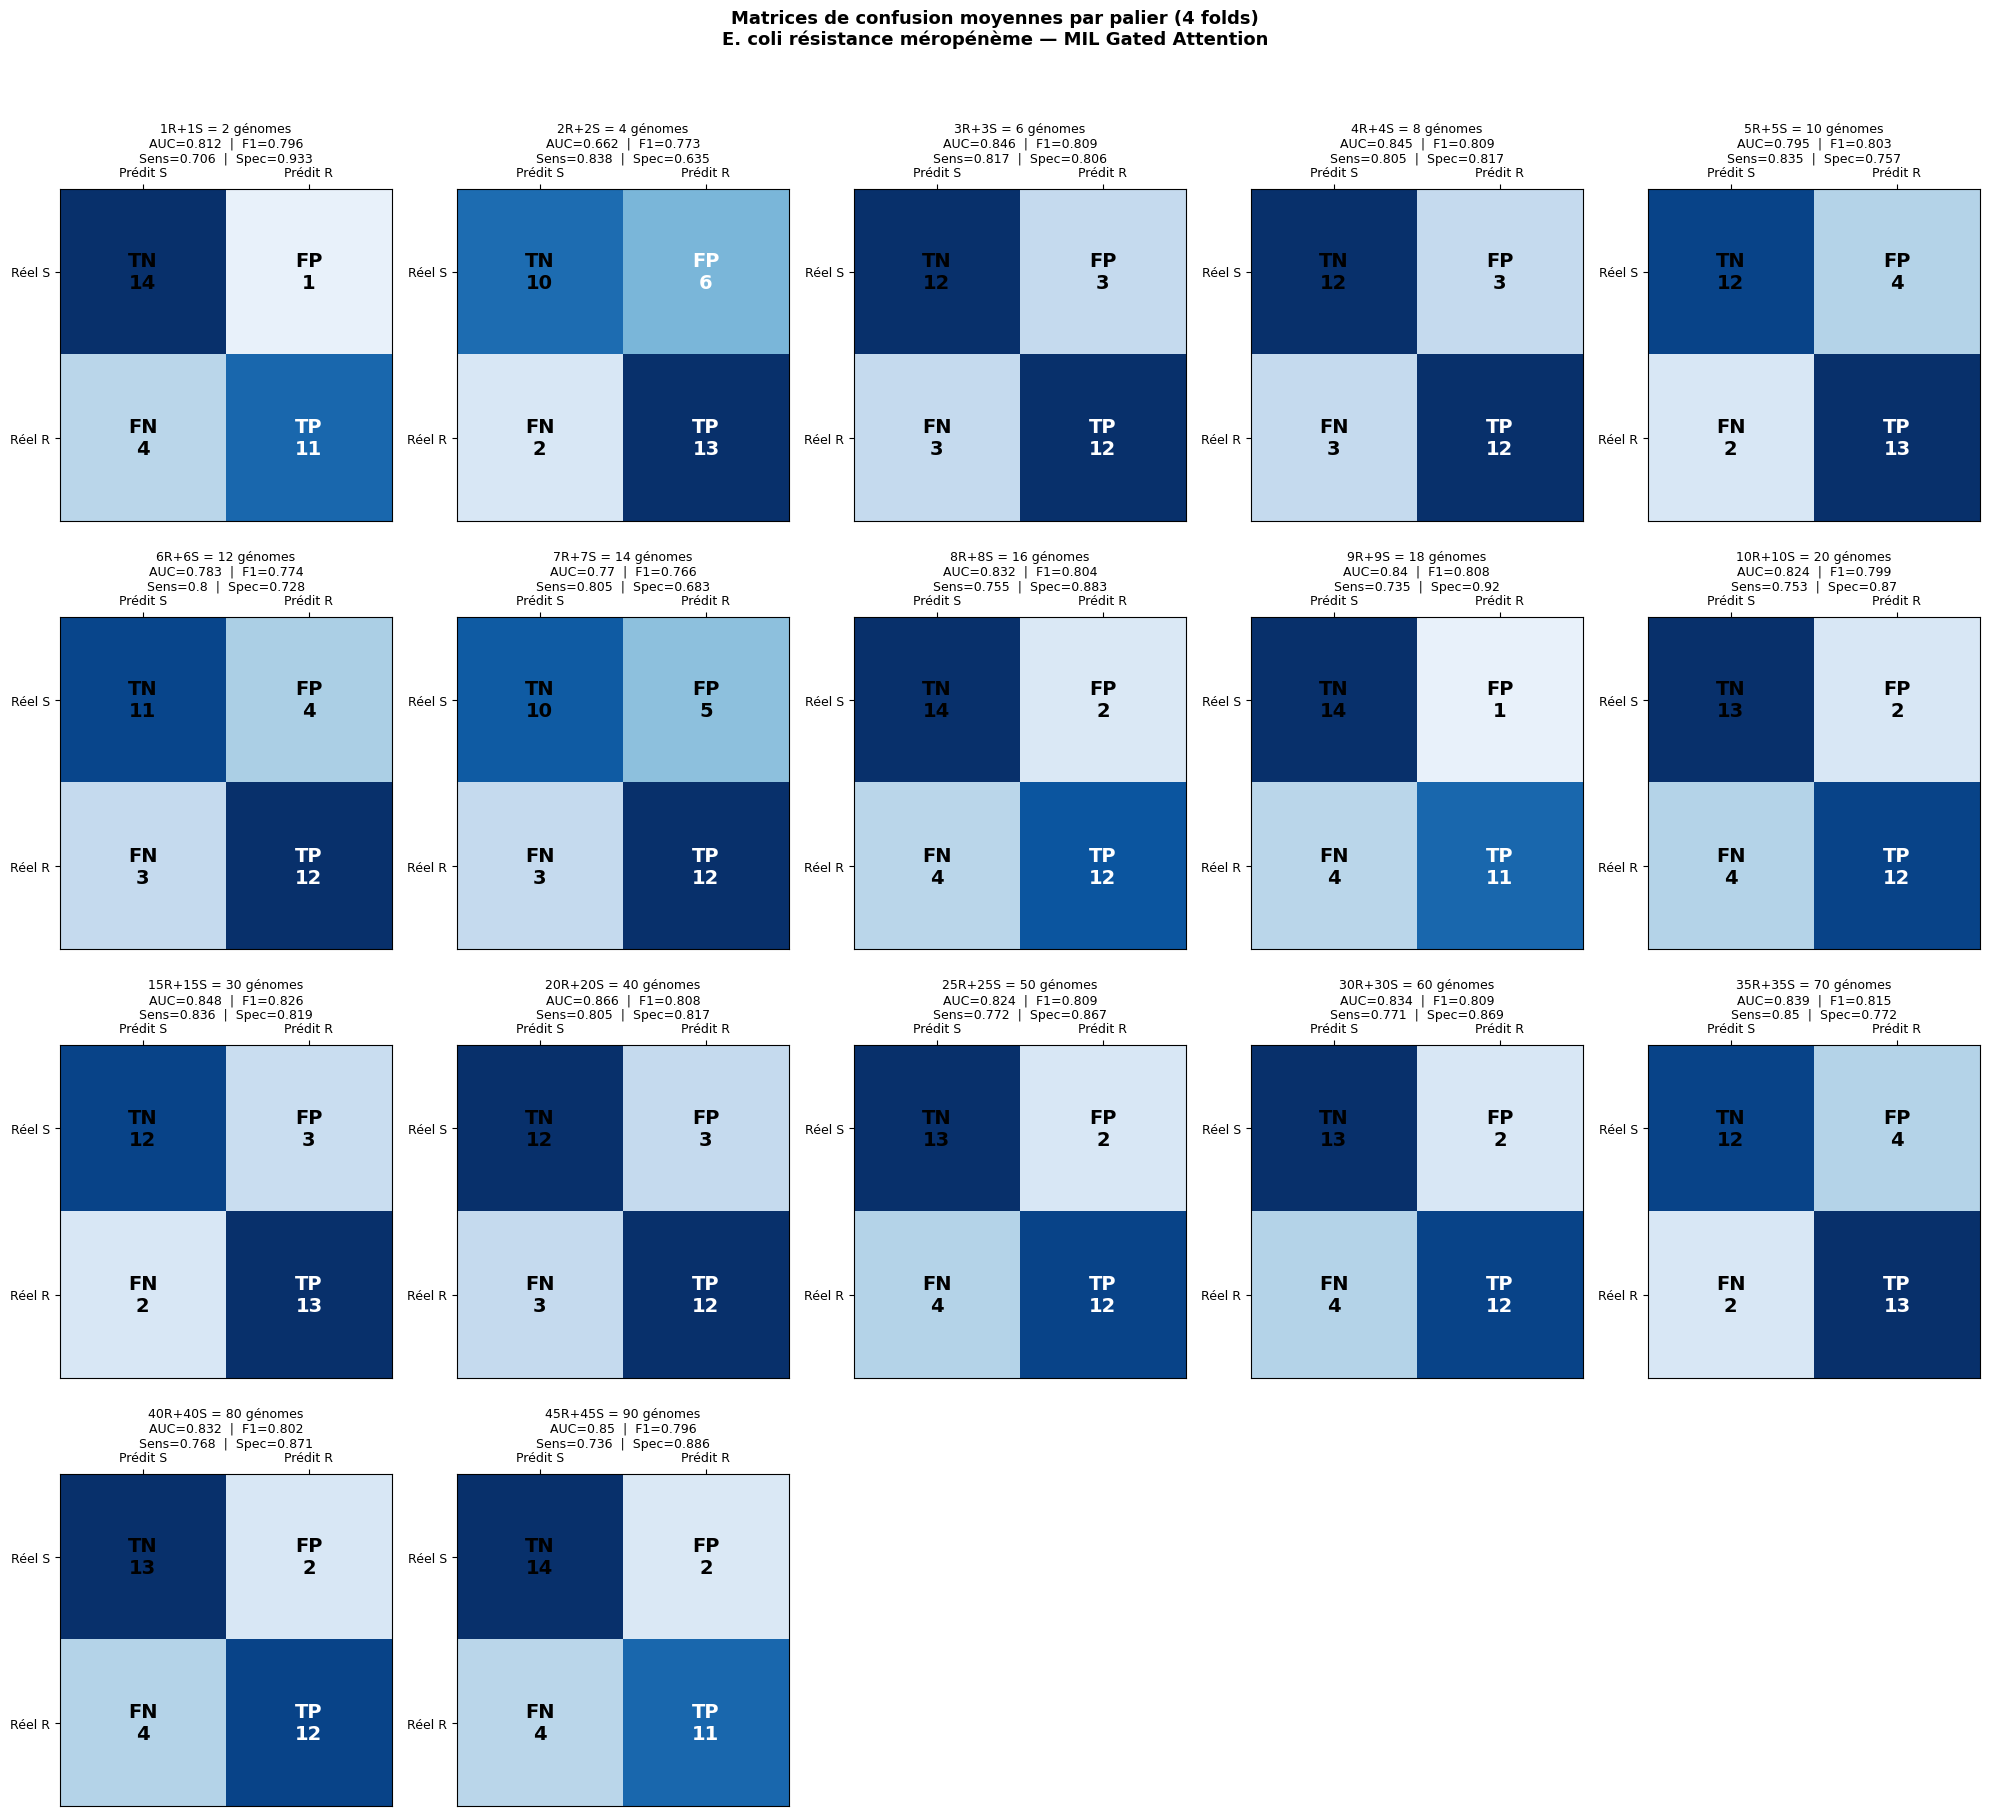

Figure sauvegardée → confusion_matrices_MIL.png


In [9]:
# Matrices de confusion par palier

from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

n_paliers = len(lc_results)
n_cols    = 5
n_rows    = (n_paliers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 4.5))
axes = axes.flatten()

for ax_idx, r in enumerate(lc_results):
    ax = axes[ax_idx]

    # Moyenne des TP/TN/FP/FN sur les 4 folds
    TP = round(np.mean(r["fold_TP"]))
    TN = round(np.mean(r["fold_TN"]))
    FP = round(np.mean(r["fold_FP"]))
    FN = round(np.mean(r["fold_FN"]))

    cm = np.array([[TN, FP],
                   [FN, TP]])

    # Affichage matrice
    im = ax.imshow(cm, cmap="Blues", vmin=0)

    # Valeurs dans les cases
    ax.text(0, 0, f"TN\n{TN}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="black")
    ax.text(1, 0, f"FP\n{FP}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white" if FP > TN/2 else "black")
    ax.text(0, 1, f"FN\n{FN}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white" if FN > TN/2 else "black")
    ax.text(1, 1, f"TP\n{TP}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white")

    # Axes
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Prédit S", "Prédit R"], fontsize=9)
    ax.set_yticklabels(["Réel S", "Réel R"], fontsize=9)
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()

    # Titre + métriques
    sens = round(r["sens_mean"], 3)
    spec = round(r["spec_mean"], 3)
    ax.set_title(
        f"{r['n_per_class']}R+{r['n_per_class']}S = {r['n_total']} génomes\n"
        f"AUC={round(r['auc_mean'],3)}  |  F1={round(r['f1_mean'],3)}\n"
        f"Sens={sens}  |  Spec={spec}",
        fontsize=9, pad=3
    )

# Masquer les axes vides
for ax_idx in range(len(lc_results), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Matrices de confusion moyennes par palier (4 folds)\n"
    "E. coli résistance méropénème — MIL Gated Attention",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("confusion_matrices_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée → confusion_matrices_MIL.png")

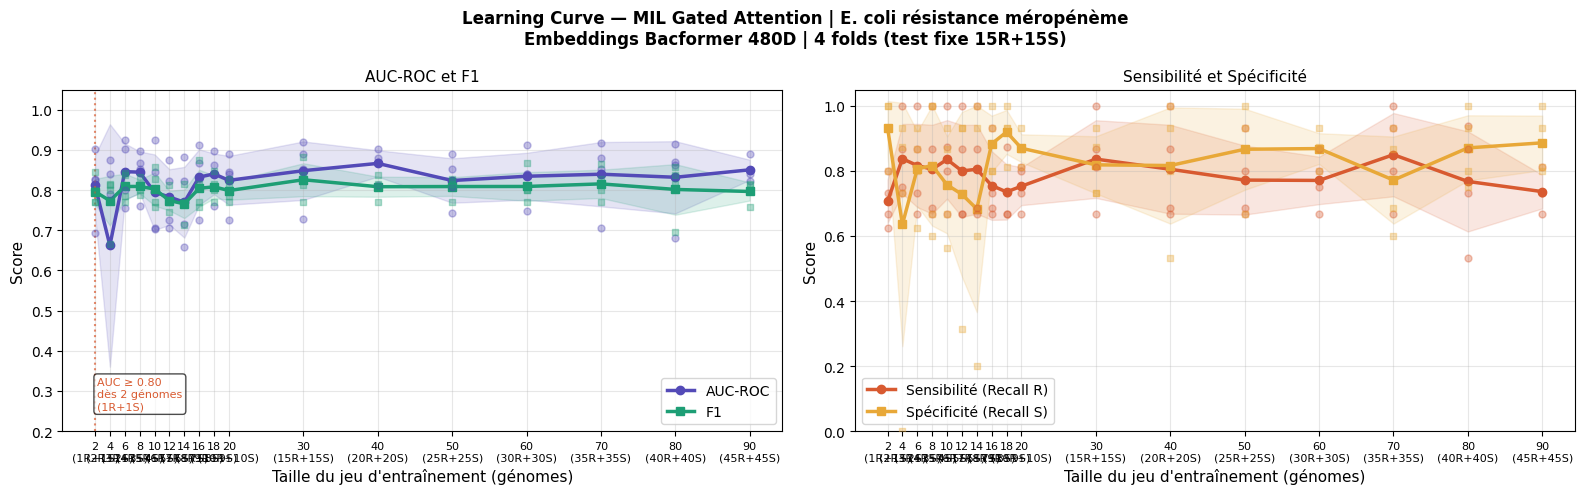

In [10]:
# Visualisation — AUC + F1 + Sens + Spec

sizes_plot = [r["n_total"]   for r in lc_results]
auc_means  = [r["auc_mean"]  for r in lc_results]
auc_stds   = [r["auc_std"]   for r in lc_results]
f1_means   = [r["f1_mean"]   for r in lc_results]
f1_stds    = [r["f1_std"]    for r in lc_results]
sens_means = [r["sens_mean"] for r in lc_results]
sens_stds  = [r["sens_std"]  for r in lc_results]
spec_means = [r["spec_mean"] for r in lc_results]
spec_stds  = [r["spec_std"]  for r in lc_results]

COLOR_AUC  = "#534AB7"
COLOR_F1   = "#1D9E75"
COLOR_SENS = "#D85A30"
COLOR_SPEC = "#E8A838"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Learning Curve — MIL Gated Attention | E. coli résistance méropénème\n"
    "Embeddings Bacformer 480D | 4 folds (test fixe 15R+15S)",
    fontsize=12, fontweight="bold"
)

# Graphe 1 : AUC + F1 
ax = axes[0]

ax.plot(sizes_plot, auc_means, marker="o", linewidth=2.5,
        color=COLOR_AUC, label="AUC-ROC")
ax.fill_between(sizes_plot,
                np.array(auc_means) - np.array(auc_stds),
                np.array(auc_means) + np.array(auc_stds),
                alpha=0.15, color=COLOR_AUC)

ax.plot(sizes_plot, f1_means, marker="s", linewidth=2.5,
        color=COLOR_F1, label="F1")
ax.fill_between(sizes_plot,
                np.array(f1_means) - np.array(f1_stds),
                np.array(f1_means) + np.array(f1_stds),
                alpha=0.15, color=COLOR_F1)

# Points individuels (toutes les répétitions)
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["fold_aucs"]), r["fold_aucs"],
               color=COLOR_AUC, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["fold_f1s"]),  r["fold_f1s"],
               color=COLOR_F1,  alpha=0.35, s=25, zorder=5, marker="s")



# Annotation premier palier AUC ≥ 0.80
first_good = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
if first_good is not None:
    s = sizes_plot[first_good]
    ax.axvline(x=s, color="#D85A30", linestyle=":", alpha=0.7, linewidth=1.5)
    ax.text(s + 0.3, 0.25,
            f"AUC ≥ 0.80\ndès {s} génomes\n({s//2}R+{s//2}S)",
            fontsize=8, color="#D85A30", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("AUC-ROC et F1", fontsize=11)
ax.set_ylim(0.2, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

# Graphe 2 : Sensibilité + Spécificité
ax = axes[1]

ax.plot(sizes_plot, sens_means, marker="o", linewidth=2.5,
        color=COLOR_SENS, label="Sensibilité (Recall R)")
ax.fill_between(sizes_plot,
                np.array(sens_means) - np.array(sens_stds),
                np.array(sens_means) + np.array(sens_stds),
                alpha=0.15, color=COLOR_SENS)

ax.plot(sizes_plot, spec_means, marker="s", linewidth=2.5,
        color=COLOR_SPEC, label="Spécificité (Recall S)")
ax.fill_between(sizes_plot,
                np.array(spec_means) - np.array(spec_stds),
                np.array(spec_means) + np.array(spec_stds),
                alpha=0.15, color=COLOR_SPEC)

# Points individuels
for r in lc_results:
    ax.scatter([r["n_total"]] * len(r["fold_sens"]), r["fold_sens"],
               color=COLOR_SENS, alpha=0.35, s=25, zorder=5)
    ax.scatter([r["n_total"]] * len(r["fold_spec"]), r["fold_spec"],
               color=COLOR_SPEC, alpha=0.35, s=25, zorder=5, marker="s")

ax.set_xlabel("Taille du jeu d'entraînement (génomes)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Sensibilité et Spécificité", fontsize=11)
ax.set_ylim(0.0, 1.05)
ax.set_xticks(sizes_plot)
ax.set_xticklabels([f"{s}\n({s//2}R+{s//2}S)" for s in sizes_plot], fontsize=8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
#print(" Figure sauvegardée → learning_curve_MIL.png")

In [11]:
print("=" * 60)
print("                      INTERPRÉTATION")
print("=" * 60)

best_auc_i = int(np.argmax(auc_means))
best_f1_i  = int(np.argmax(f1_means))
first_80   = next((i for i, a in enumerate(auc_means) if a >= 0.80), None)
first_90   = next((i for i, a in enumerate(auc_means) if a >= 0.90), None)

print(f"\n  Meilleure AUC : {auc_means[best_auc_i]:.3f} ± {auc_stds[best_auc_i]:.3f}")
print(f"    → {sizes_plot[best_auc_i]} génomes ({sizes_plot[best_auc_i]//2}R + {sizes_plot[best_auc_i]//2}S)")

print(f"\n  Meilleur F1   : {f1_means[best_f1_i]:.3f} ± {f1_stds[best_f1_i]:.3f}")
print(f"    → {sizes_plot[best_f1_i]} génomes ({sizes_plot[best_f1_i]//2}R + {sizes_plot[best_f1_i]//2}S)")

if first_80 is not None:
    s = sizes_plot[first_80]
    print(f"\n   AUC ≥ 0.80 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_90 is not None:
    s = sizes_plot[first_90]
    print(f"   AUC ≥ 0.90 atteinte dès {s} génomes ({s//2}R+{s//2}S)")

if first_80 is None:
    print("    AUC < 0.80 sur tous les paliers")

print("\n" + "=" * 60)

                      INTERPRÉTATION

  Meilleure AUC : 0.866 ± 0.033
    → 40 génomes (20R + 20S)

  Meilleur F1   : 0.826 ± 0.041
    → 30 génomes (15R + 15S)

   AUC ≥ 0.80 atteinte dès 2 génomes (1R+1S)



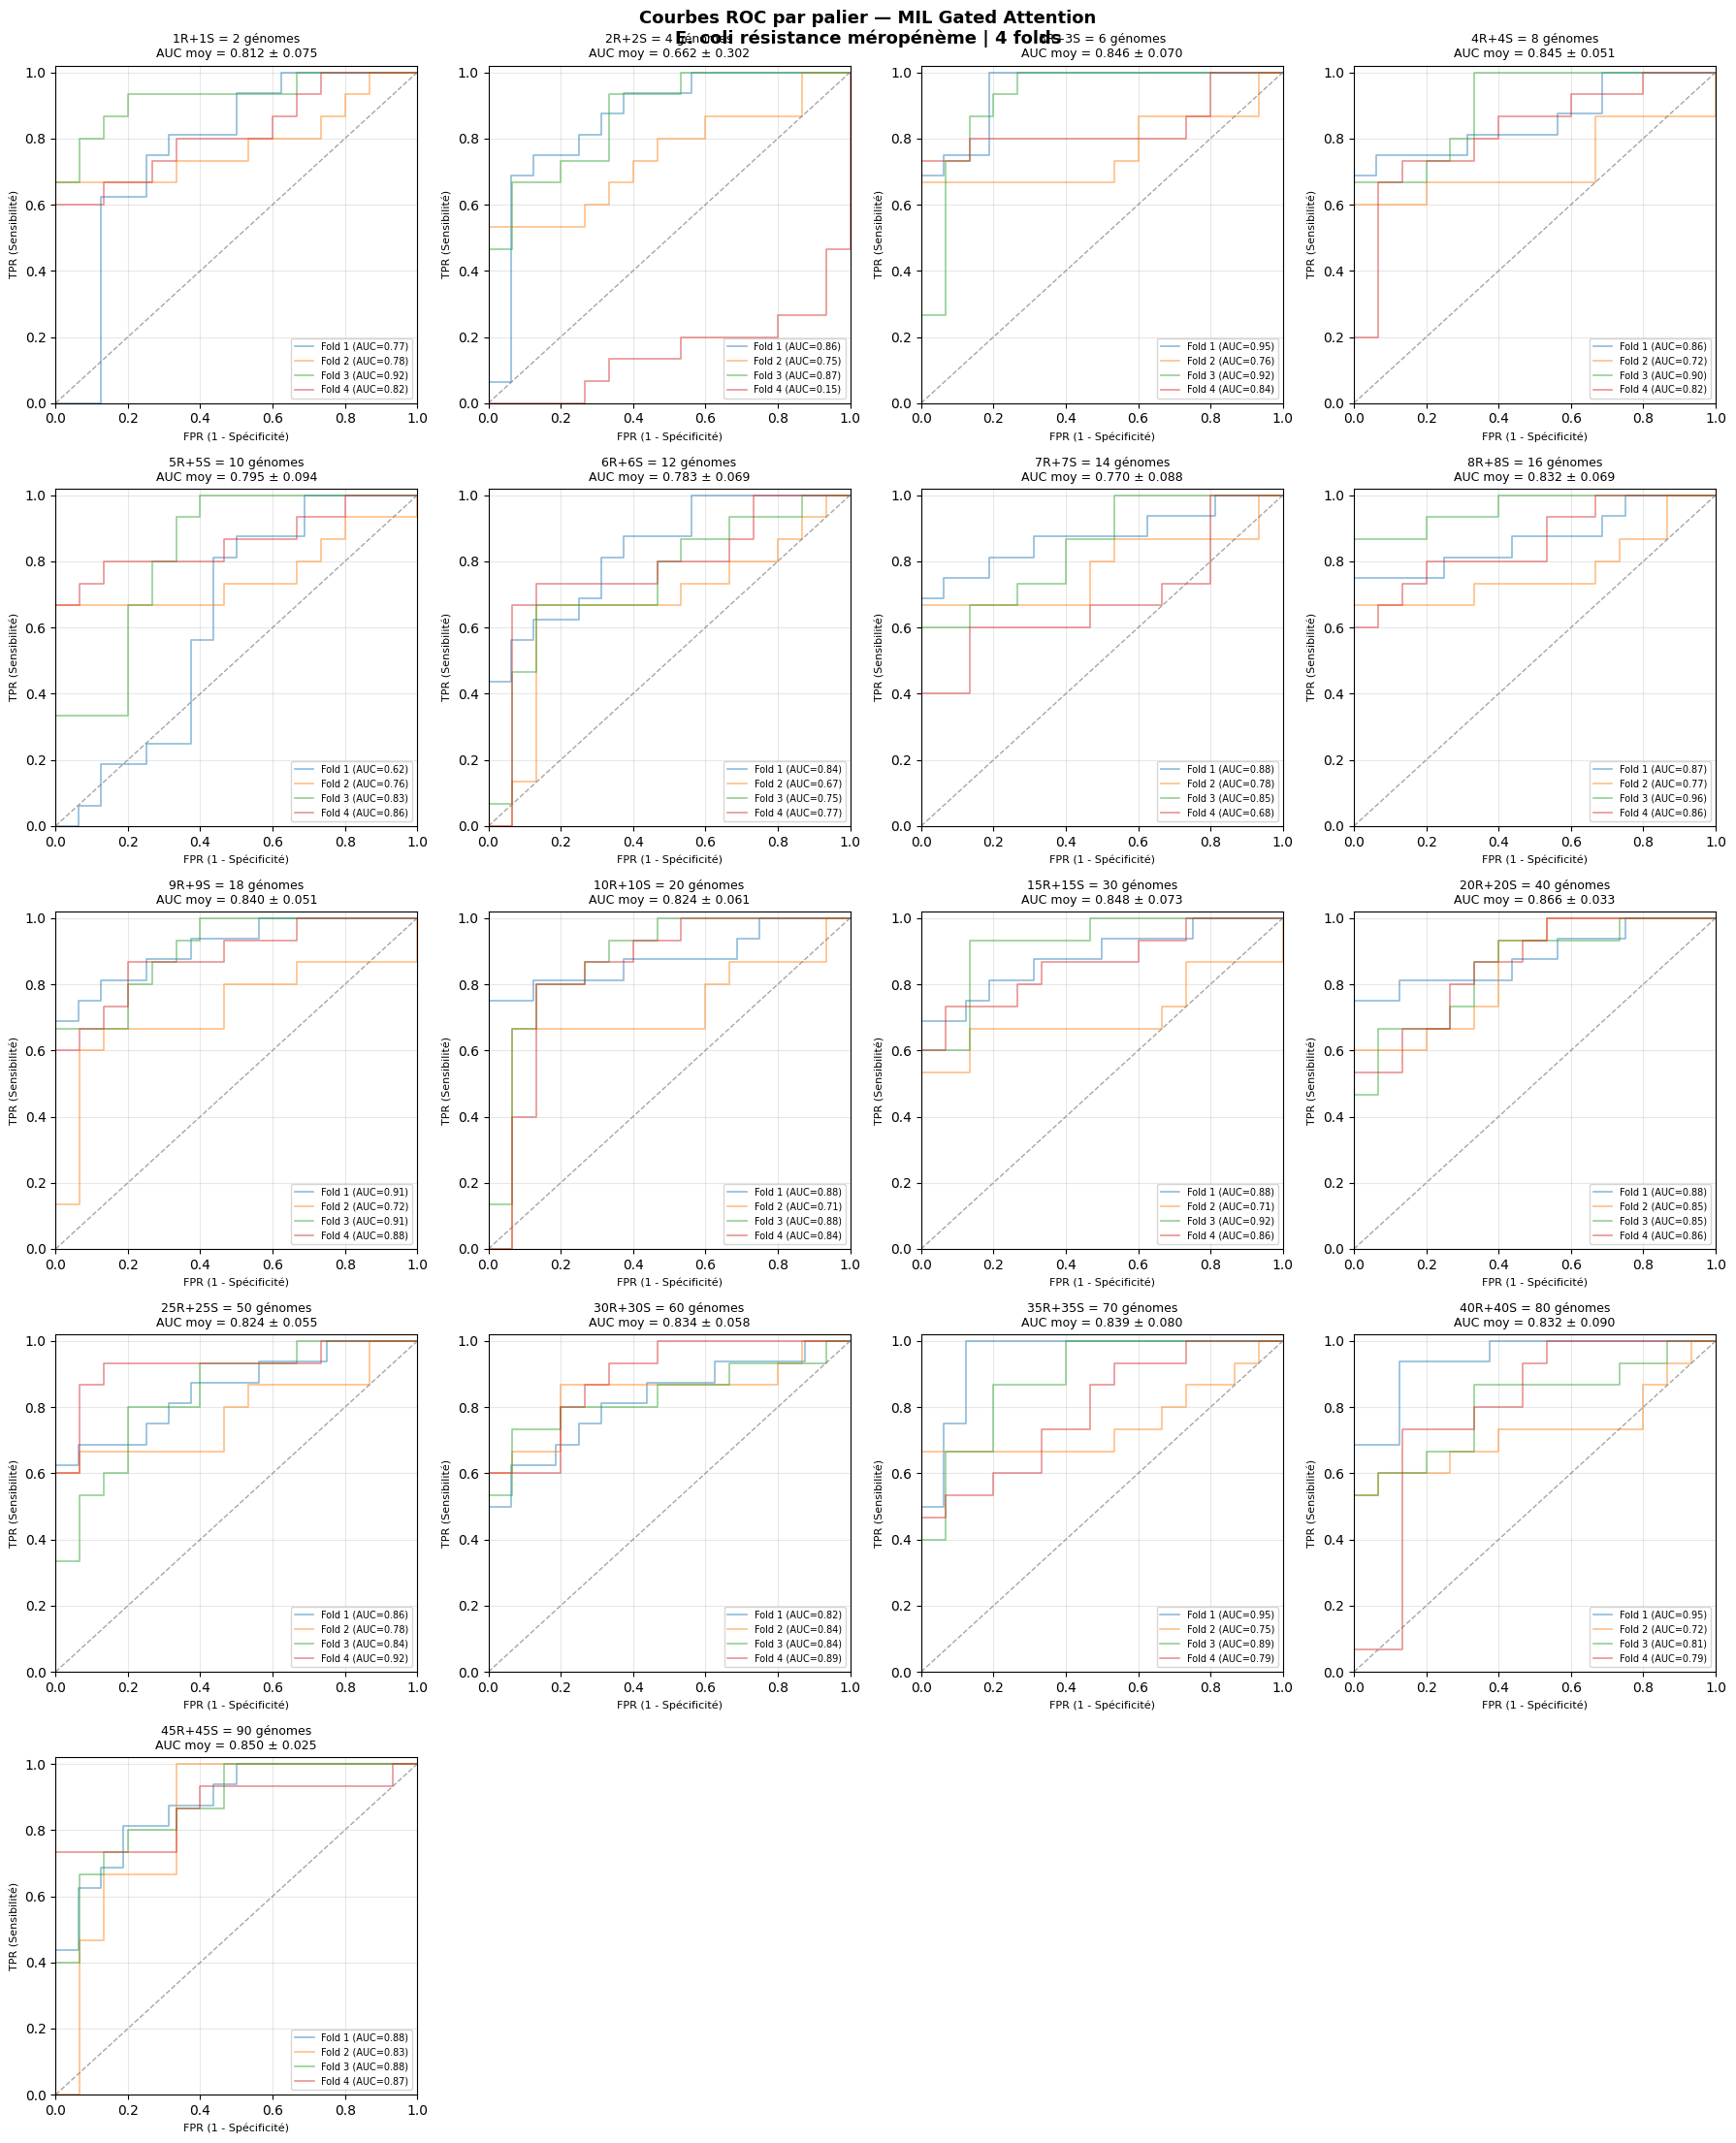

In [12]:
# Courbes ROC par palier

from sklearn.metrics import roc_curve, auc

n_paliers = len(lc_results)  
n_cols    = 4
n_rows    = (n_paliers + n_cols - 1) // n_cols  # calcul automatique du nb de lignes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))
axes = axes.flatten()

colors = plt.cm.viridis(np.linspace(0, 1, len(lc_results)))

for ax_idx, r in enumerate(lc_results):
    ax = axes[ax_idx]

    n_per_class = r["n_per_class"]

    # Recalcule les courbes ROC pour chaque fold
    for fold_idx in range(N_FOLDS):

        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)

        # Reconstruit test set du fold
        te_R = fold_test_R[fold_idx]
        te_S = np.random.choice(susceptible_idx, size=len(te_R), replace=False)
        te_files = [matched[i] for i in np.concatenate([te_R, te_S])]
        te_ds    = GenomeMILDataset(te_files, id_to_y)
        te_loader = DataLoader(te_ds, batch_size=4, shuffle=False,
                               collate_fn=mil_collate)

        # Charge le meilleur modèle du palier
        model_roc = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        #model_roc.load_state_dict(best_models[n_per_class])
        model_roc.load_state_dict(all_fold_models[n_per_class][fold_idx])
        model_roc.eval()

        test_y, test_prob = get_probs(model_roc, te_loader)

        if len(np.unique(test_y)) > 1:
            fpr, tpr, _ = roc_curve(test_y, test_prob)
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=1.2, alpha=0.5,
                    label=f"Fold {fold_idx+1} (AUC={roc_auc:.2f})")

    # Courbe moyenne (AUC moyen)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
            linewidth=1, alpha=0.7)

    ax.set_title(
        f"{n_per_class}R+{n_per_class}S = {2*n_per_class} génomes\n"
        f"AUC moy = {r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
        fontsize=9
    )
    ax.set_xlabel("FPR (1 - Spécificité)", fontsize=8)
    ax.set_ylabel("TPR (Sensibilité)", fontsize=8)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

# Masque axes vides
for ax_idx in range(len(lc_results), len(axes)):
    axes[ax_idx].set_visible(False)

fig.suptitle(
    "Courbes ROC par palier — MIL Gated Attention\n"
    "E. coli résistance méropénème | 4 folds",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
#plt.savefig("roc_curves_MIL.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Figure sauvegardée → roc_curves_MIL.png")

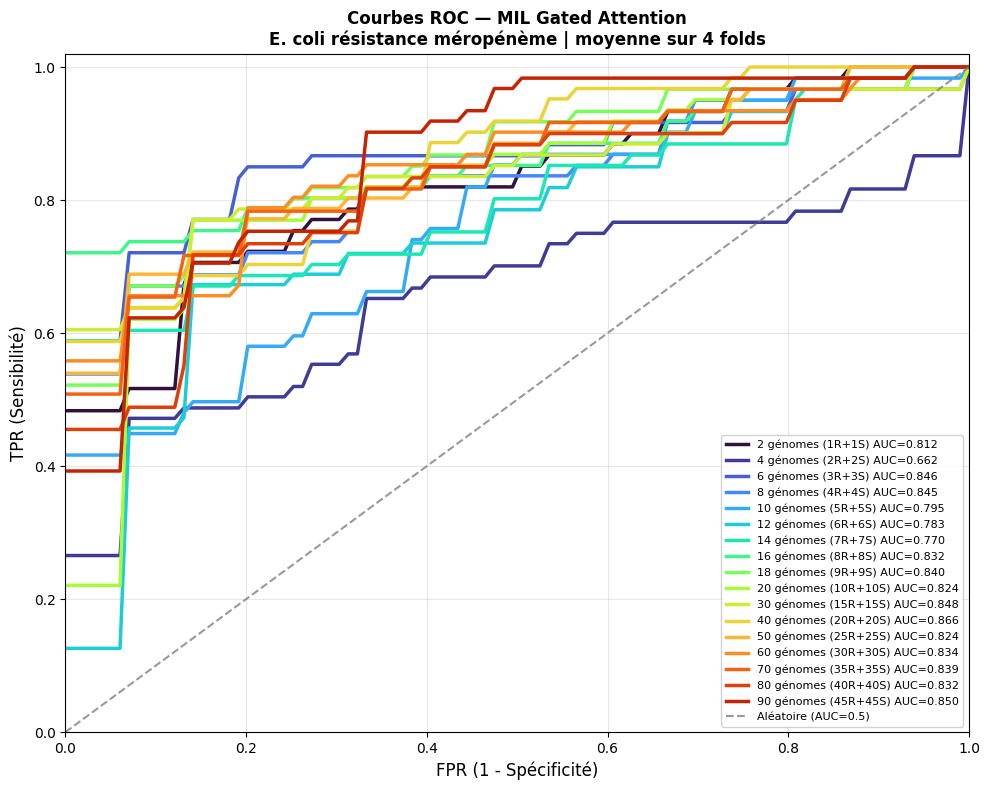

In [31]:
# Courbes ROC : tous paliers sur mm graphe
fig, ax = plt.subplots(figsize=(10, 8))

# Dégradé de couleurs
colors     = plt.cm.turbo(np.linspace(0.0, 0.9, len(lc_results)))  # tester (plasma, viridis, coolwarm, RdYlGn,turbo, rainbow)
linestyles = ["-"] * len(lc_results)
#linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-"]

for i, (r, color, ls) in enumerate(zip(lc_results, colors, linestyles)):
    n_per_class = r["n_per_class"]
    all_fpr     = np.linspace(0, 1, 100)
    all_tpr     = []

    for fold_idx in range(N_FOLDS):
        seed_run = SEED + fold_idx * 100 + n_per_class
        set_seed(seed_run)
        te_R = fold_test_R[fold_idx]
        te_S = np.random.choice(susceptible_idx, size=len(te_R), replace=False)
        te_files  = [matched[i] for i in np.concatenate([te_R, te_S])]
        te_ds     = GenomeMILDataset(te_files, id_to_y)
        te_loader = DataLoader(te_ds, batch_size=4, shuffle=False,
                               collate_fn=mil_collate)
        model_roc = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
        model_roc.load_state_dict(all_fold_models[n_per_class][fold_idx])
        model_roc.eval()
        test_y, test_prob = get_probs(model_roc, te_loader)
        if len(np.unique(test_y)) > 1:
            fpr, tpr, _ = roc_curve(test_y, test_prob)
            tpr_interp  = np.interp(all_fpr, fpr, tpr)
            all_tpr.append(tpr_interp)

    if all_tpr:
        mean_tpr = np.mean(all_tpr, axis=0)
        mean_auc = r["auc_mean"]
        ax.plot(all_fpr, mean_tpr,
                linewidth=2.5,
                linestyle=ls,
                color=color,
                label=f"{2*n_per_class} génomes ({n_per_class}R+{n_per_class}S) "
                      f"AUC={mean_auc:.3f}")
        # ← fill_between supprimé !

# Diagonale aléatoire
ax.plot([0, 1], [0, 1], linestyle="--", color="gray",
        linewidth=1.5, alpha=0.8, label="Aléatoire (AUC=0.5)")
ax.set_xlabel("FPR (1 - Spécificité)", fontsize=12)
ax.set_ylabel("TPR (Sensibilité)", fontsize=12)
ax.set_title(
    "Courbes ROC — MIL Gated Attention\n"
    "E. coli résistance méropénème | moyenne sur 4 folds",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=8, loc="lower right",
          framealpha=0.9, ncol=1)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
#plt.savefig("roc_curves_combined.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Fonction load_labels + load_pt
PT_DIR   = "embeddings_out"
GBK_DIR  = "genomes_gbff"
RGI_DIR  = "rgi_results"
LABELS_PATH = "matrice_listantibio_final.cleaned.list"
 
def load_labels(path):
    df = pd.read_csv(path, sep="\t", dtype=str)
    df["#Genome_ID_Genome_name"] = df["#Genome_ID_Genome_name"].astype(str)
    df["Resistant"]   = df["Resistant"].astype(int)
    df["Susceptible"] = df["Susceptible"].astype(int)
    return dict(zip(df["#Genome_ID_Genome_name"], df["Resistant"].astype(int)))
 
def load_pt(fp):
    obj = torch.load(fp)
    gid = str(obj.get("genome_id", os.path.splitext(os.path.basename(fp))[0]))
    X   = obj["last_hidden_state"]
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if X.ndim == 3:
        X = X.squeeze(0)
    if X.ndim != 2:
        raise ValueError(f"{fp}: shape inattendue {tuple(X.shape)}")
    return gid, X.float()
 
# Charge labels + fichiers
id_to_y   = load_labels(LABELS_PATH)
all_files = sorted(glob.glob(os.path.join(PT_DIR, "*.pt")))
matched   = [fp for fp in all_files if load_pt(fp)[0] in id_to_y]
resistant_files  = [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 1]
susceptible_files= [fp for fp in matched if id_to_y[load_pt(fp)[0]] == 0]
 
print(f"Labels chargés")
print(f"Total .pt matchés  : {len(matched)}")
print(f"Résistants         : {len(resistant_files)}")
print(f"Sensibles          : {len(susceptible_files)}")

Labels chargés
Total .pt matchés  : 1006
Résistants         : 61
Sensibles          : 945


In [15]:
# IDs dans tes .pt
pt_ids  = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("embeddings_out/*.pt"))

# IDs dans tes résultats RGI
rgi_ids = set(os.path.splitext(os.path.basename(f))[0]
              for f in glob.glob("rgi_results/*.txt"))

# IDs dans tes .gbff
gbff_ids = set(os.path.splitext(os.path.basename(f))[0]
               for f in glob.glob("genomes_gbff/*.gbff"))

print(f"IDs dans .pt   : {len(pt_ids)}")
print(f"IDs dans RGI   : {len(rgi_ids)}")
print(f"IDs dans .gbff : {len(gbff_ids)}")

IDs dans .pt   : 1066
IDs dans RGI   : 1066
IDs dans .gbff : 1066


In [16]:
# Parser le .gbff pour extraire les CDS dans l'ordre
from Bio import SeqIO

def load_gbff_annotation(genome_id):
    gbff_file = os.path.join(GBK_DIR, f"{genome_id}.gbff")
    if not os.path.exists(gbff_file):
        print(f"Fichier non trouvé : {gbff_file}")
        return None
    rows = []
    for record in SeqIO.parse(gbff_file, "genbank"):
        for feature in record.features:
            if feature.type != "CDS":
                continue
            rows.append({
                "contig":    record.id,
                "start":     int(feature.location.start),
                "end":       int(feature.location.end),
                "strand":    int(feature.location.strand),
                "locus_tag": feature.qualifiers.get("locus_tag", [""])[0],
                "gene":      feature.qualifiers.get("gene",      [""])[0],
                "product":   feature.qualifiers.get("product",   ["unknown"])[0],
            })
    if not rows:
        print(f"Aucun CDS trouvé")
        return None
    df = pd.DataFrame(rows).reset_index()
    return df.rename(columns={"index": "protein_index"})
 
# Test sur le premier génome disponible
sample_gid = load_pt(all_files[0])[0]
ann_test   = load_gbff_annotation(sample_gid)
 
if ann_test is not None:
    print(f".gbff chargé pour : {sample_gid}")
    print(f"   Nb CDS : {len(ann_test)}")
    print(ann_test[["protein_index","gene","product","start","end"]].head(10))
else:
    print("Problème — vérifie GBK_DIR et le nom des fichiers")

.gbff chargé pour : 1328432.3
   Nb CDS : 4665
   protein_index    gene                                            product  \
0              0    thrA  Bifunctional aspartokinase/homoserine dehydrog...   
1              1    thrB                                  Homoserine kinase   
2              2    thrC                                 Threonine synthase   
3              3                                       hypothetical protein   
4              4    yaaA  DNA-binding and peroxide stress resistance pro...   
5              5    alsT                    Amino-acid carrier protein AlsT   
6              6  talB_1                                    Transaldolase B   
7              7     mog                  Molybdopterin adenylyltransferase   
8              8    satP            Succinate-acetate/proton symporter SatP   
9              9                                       hypothetical protein   

   start    end  
0    335   2798  
1   2799   3732  
2   3732   5019  
3   5232   

In [17]:
# Parser les résultats RGI
 
def load_rgi_meropenem(genome_id):
    rgi_file = os.path.join(RGI_DIR, f"{genome_id}.txt")
    if not os.path.exists(rgi_file):
        return None

    df = pd.read_csv(rgi_file, sep="\t")

    # Garde Perfect + Strict uniquement
    df = df[df["Cut_Off"].isin(["Perfect", "Strict"])].copy()
    if len(df) == 0:
        return None

    # ── Filtre méropénème sur "Drug Class" ───
    mask = df["Drug Class"].str.lower().str.contains(
        "carbapenem|penem", na=False
    )
    df = df[mask].copy()
    if len(df) == 0:
        return None

    # Parse start/stop depuis Start/Stop
    df["rgi_start"] = df["Start"].astype(int)
    df["rgi_stop"]  = df["Stop"].astype(int)

    return df.reset_index(drop=True)

# Test sur le premier génome résistant
test_gid = load_pt(resistant_files[0])[0]
rgi_test = load_rgi_meropenem(test_gid)

print(f"Test RGI méropénème sur : {test_gid}")
if rgi_test is not None:
    print(f"   Nb gènes carbapénème détectés : {len(rgi_test)}")
    print(rgi_test[["Best_Hit_ARO", "Drug Class", "Cut_Off", "Best_Identities"]].to_string(index=False))
else:
    print("Aucun gène carbapénème trouvé")
    # Diagnostic — affiche tous les Drug Class trouvés
    df_all = pd.read_csv(os.path.join(RGI_DIR, f"{test_gid}.txt"), sep="\t")
    df_all = df_all[df_all["Cut_Off"].isin(["Perfect","Strict"])]
    print(f"\n   Tous les Drug Class trouvés :")
    for dc in df_all["Drug Class"].unique():
        print(f"     → {dc}")

Test RGI méropénème sur : 1328437.3
   Nb gènes carbapénème détectés : 3
                                                        Best_Hit_ARO                                                                                                                                                                                                        Drug Class Cut_Off  Best_Identities
                                                                marA fluoroquinolone antibiotic; monobactam; carbapenem; cephalosporin; glycylcycline; penicillin beta-lactam; tetracycline antibiotic; rifamycin antibiotic; phenicol antibiotic; disinfecting agents and antiseptics Perfect            100.0
                                                               KPC-2                                                                                                                                                     monobactam; carbapenem; cephalosporin; penicillin beta-lactam Perfect            100.0
Escherichia col

In [18]:
# top protéines annotées

N_BEST = 35   #  changer le palier : 10, 15, 20, 25, 30, 35, 40

# Vérification
assert N_BEST in best_models, \
    f"Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f"Modèle chargé : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1_mean']:.3f} ± {r_info['f1_std']:.3f}")
print(f"   AUC par fold : {[round(a,3) for a in r_info['fold_aucs']]}")
print(f"   Meilleur fold : {r_info['best_fold']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y) #applique le modèle sur tous tes 907 génomes (pas juste le test) 
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

# Fonction
def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=10)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
sensible_ann  = [r for r in top_attn_ann if r["true_label"] == 0]
correct_R     = sum(1 for r in resistant_ann if r["correct"])
correct_S     = sum(1 for r in sensible_ann  if r["correct"])

# Affichage (5 génomes)
def affiche_genomes(genome_list, label_str, n_display=5):
    correct = sum(1 for r in genome_list if r["correct"])
    print(f"\n{'#'*85}")
    print(f"  {label_str} ({len(genome_list)} génomes total) "
          f"— Prédictions correctes : {correct}/{len(genome_list)} "
          f"({correct/len(genome_list):.1%})")
    print(f"  Affichage des {min(n_display, len(genome_list))} premiers")
    print(f"{'#'*85}")

    for r in genome_list[:n_display]:   # ← seulement les 5 premiers
        icon = "CORRECT" if r["correct"] else "NOT CORRECT"
        print(f"\n{'='*85}")
        print(f"{icon}  Genome : {r['genome_id']}  |  "
              f"P(resistant)={r['predicted_prob']:.3f}  |  "
              f"{r['n_proteins']} protéines  |  "
              f"Entropie : {r['attn_entropy_pct']:.1%}")
        print(f"{'='*85}")
        print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
              f"{'Gène':>12} | Produit")
        print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
        for p in r["top_proteins"]:
            print(
                f"{p['rank']:>4} | "
                f"{p['protein_index']:>6} | "
                f"{p['attention_weight']:.8f} | "
                f"{p['attention_pct']:>6.2f}% | "
                f"{p['gene']:>12} | "
                f"{str(p['product'])[:50]}"
            )


# Affichage 5 résistants + 5 sensibles
affiche_genomes(resistant_ann, "GÉNOMES RÉSISTANTS", n_display=5)
affiche_genomes(sensible_ann,  "GÉNOMES SENSIBLES",  n_display=5)

# Export CSV — TOUS les génomes
def build_rows(genome_list):
    rows = []
    for r in genome_list:
        for p in r["top_proteins"]:
            rows.append({
                "genome_id":        r["genome_id"],
                "true_label":       r["true_label"],
                "predicted_prob":   round(r["predicted_prob"], 4),
                "correct":          r["correct"],
                "n_proteins":       r["n_proteins"],
                "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
                **p
            })
    return rows

# CSV résistants : tous les 53R
df_R = pd.DataFrame(build_rows(resistant_ann))
df_R.to_csv(f"top_attention_{N_BEST}R_resistants.csv", index=False)
print(f"\n Export résistants → top_attention_{N_BEST}R_resistants.csv "
      f"({len(resistant_ann)} génomes | {len(df_R)} lignes)")

# CSV sensibles : tous les S
df_S = pd.DataFrame(build_rows(sensible_ann))
df_S.to_csv(f"top_attention_{N_BEST}R_sensibles.csv", index=False)
print(f" Export sensibles  → top_attention_{N_BEST}R_sensibles.csv "
      f"({len(sensible_ann)} génomes | {len(df_S)} lignes)")

# Affichage DataFrame (5 de chaque)
#print(f"\n{'='*85}")
#print(f"DATAFRAME — RÉSISTANTS (5 premiers sur {len(resistant_ann)})")
#"print(f"{'='*85}")
#display(
 #   df_R[df_R["genome_id"].isin(
  #      [r["genome_id"] for r in resistant_ann[:5]]
   # )]
    #.sort_values(["genome_id", "rank"])
    #.reset_index(drop=True)
#)

#print(f"\n{'='*85}")
#print(f"DATAFRAME — SENSIBLES (5 premiers sur {len(sensible_ann)})")
#print(f"{'='*85}")
#display(
 #   df_S[df_S["genome_id"].isin(
  #      [r["genome_id"] for r in sensible_ann[:5]]
   # )]
    #.sort_values(["genome_id", "rank"])
    #.reset_index(drop=True)
#)

Modèle chargé : palier 35R+35S = 70 génomes
   AUC  : 0.839 ± 0.080
   F1   : 0.815 ± 0.035
   AUC par fold : [0.918, 0.707, 0.88, 0.853]
   Meilleur fold : 1


#####################################################################################
  GÉNOMES RÉSISTANTS (61 génomes total) — Prédictions correctes : 51/61 (83.6%)
  Affichage des 5 premiers
#####################################################################################

CORRECT  Genome : 1328437.3  |  P(resistant)=0.877  |  5202 protéines  |  Entropie : 79.5%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   5134 | 0.01892849 |   1.89% |       parB_2 | Protein ParB
   2 |   4606 | 0.01586795 |   1.59% |            — | hypothetical protein
   3 |   5198 | 0.01491093 |   1.49% |            ? | ?
   4 |   5200 | 0.01397933 |   1.40% |            ? | ?
   5 |   4418 | 0.01161272 |   1.16% |            — | hyp

In [32]:
# top protéines annotées

N_BEST = 45   #  changer le palier : 10, 15, 20, 25, 30, 35, 40

# Vérification
assert N_BEST in best_models, \
    f"Palier {N_BEST} non disponible. Paliers dispo : {list(best_models.keys())}"

model_best = GatedAttentionMIL(emb_dim, ATTN_DIM, HIDDEN, DROPOUT).to(device)
model_best.load_state_dict(best_models[N_BEST])
model_best.eval()

r_info = next(x for x in lc_results if x["n_per_class"] == N_BEST)
print(f"Modèle chargé : palier {N_BEST}R+{N_BEST}S = {2*N_BEST} génomes")
print(f"   AUC  : {r_info['auc_mean']:.3f} ± {r_info['auc_std']:.3f}")
print(f"   F1   : {r_info['f1_mean']:.3f} ± {r_info['f1_std']:.3f}")
print(f"   AUC par fold : {[round(a,3) for a in r_info['fold_aucs']]}")
print(f"   Meilleur fold : {r_info['best_fold']}\n")

# Full eval loader
full_dataset     = GenomeMILDataset(matched, id_to_y) #applique le modèle sur tous tes 907 génomes (pas juste le test) 
full_eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=mil_collate)

# Fonction
def get_top_attention_with_annotation(model, loader, gbk_dir=GBK_DIR, top_k=10):
    model.eval()
    results = []
    with torch.no_grad():
        for Xpad, mask, y, gids in loader:
            Xpad, mask    = Xpad.to(device), mask.to(device)
            logits, alpha = model(Xpad, mask)
            probs         = torch.sigmoid(logits).cpu().numpy()

            for i, gid in enumerate(gids):
                n_prot  = int(mask[i].sum().item())
                attn    = alpha[i, :n_prot].cpu().numpy()
                top_idx = np.argsort(attn)[::-1][:top_k]

                entropy     = float(-np.sum(attn * np.log(attn + 1e-12)))
                max_entropy = float(np.log(n_prot))

                ann = load_gbff_annotation(gid)
                top_proteins = []
                for rank, idx in enumerate(top_idx, 1):
                    entry = {
                        "rank":             rank,
                        "protein_index":    int(idx),
                        "attention_weight": float(attn[idx]),
                        "attention_pct":    float(100 * attn[idx] / attn.sum()),
                    }
                    if ann is not None and idx < len(ann):
                        row = ann.iloc[idx]
                        entry["gene"]      = row.get("gene",      None) or "—"
                        entry["product"]   = row.get("product",   None) or "—"
                        entry["locus_tag"] = row.get("locus_tag", None) or "—"
                    else:
                        entry["gene"]      = "?"
                        entry["product"]   = "?"
                        entry["locus_tag"] = "?"
                    top_proteins.append(entry)

                results.append({
                    "genome_id":        gid,
                    "true_label":       int(y[i].item()),
                    "predicted_prob":   float(probs[i]),
                    "predicted_label":  int(probs[i] >= 0.5),
                    "correct":          int(y[i].item()) == int(probs[i] >= 0.5),
                    "n_proteins":       n_prot,
                    "attn_entropy_pct": float(entropy / max_entropy) if max_entropy > 0 else 1.0,
                    "top_proteins":     top_proteins,
                })
    return results

top_attn_ann  = get_top_attention_with_annotation(model_best, full_eval_loader, top_k=50)
resistant_ann = [r for r in top_attn_ann if r["true_label"] == 1]
sensible_ann  = [r for r in top_attn_ann if r["true_label"] == 0]
correct_R     = sum(1 for r in resistant_ann if r["correct"])
correct_S     = sum(1 for r in sensible_ann  if r["correct"])

# Affichage (5 génomes)
def affiche_genomes(genome_list, label_str, n_display=5):
    correct = sum(1 for r in genome_list if r["correct"])
    print(f"\n{'#'*85}")
    print(f"  {label_str} ({len(genome_list)} génomes total) "
          f"— Prédictions correctes : {correct}/{len(genome_list)} "
          f"({correct/len(genome_list):.1%})")
    print(f"  Affichage des {min(n_display, len(genome_list))} premiers")
    print(f"{'#'*85}")

    for r in genome_list[:n_display]:   # ← seulement les 5 premiers
        icon = "CORRECT" if r["correct"] else "NOT CORRECT"
        print(f"\n{'='*85}")
        print(f"{icon}  Genome : {r['genome_id']}  |  "
              f"P(resistant)={r['predicted_prob']:.3f}  |  "
              f"{r['n_proteins']} protéines  |  "
              f"Entropie : {r['attn_entropy_pct']:.1%}")
        print(f"{'='*85}")
        print(f"{'Rang':>4} | {'Idx':>6} | {'Poids':>10} | {'% total':>7} | "
              f"{'Gène':>12} | Produit")
        print(f"{'-'*4}-+-{'-'*6}-+-{'-'*10}-+-{'-'*7}-+-{'-'*12}-+-{'-'*40}")
        for p in r["top_proteins"]:
            print(
                f"{p['rank']:>4} | "
                f"{p['protein_index']:>6} | "
                f"{p['attention_weight']:.8f} | "
                f"{p['attention_pct']:>6.2f}% | "
                f"{p['gene']:>12} | "
                f"{str(p['product'])[:50]}"
            )


# Affichage 5 résistants + 5 sensibles
affiche_genomes(resistant_ann, "GÉNOMES RÉSISTANTS", n_display=5)
affiche_genomes(sensible_ann,  "GÉNOMES SENSIBLES",  n_display=5)

# Export CSV — TOUS les génomes
def build_rows(genome_list):
    rows = []
    for r in genome_list:
        for p in r["top_proteins"]:
            rows.append({
                "genome_id":        r["genome_id"],
                "true_label":       r["true_label"],
                "predicted_prob":   round(r["predicted_prob"], 4),
                "correct":          r["correct"],
                "n_proteins":       r["n_proteins"],
                "attn_entropy_pct": round(r["attn_entropy_pct"], 4),
                **p
            })
    return rows

# CSV résistants : tous les 53R
df_R = pd.DataFrame(build_rows(resistant_ann))
df_R.to_csv(f"top_attention_{N_BEST}R_resistants.csv", index=False)
print(f"\n Export résistants → top_attention_{N_BEST}R_resistants.csv "
      f"({len(resistant_ann)} génomes | {len(df_R)} lignes)")

# CSV sensibles : tous les S
df_S = pd.DataFrame(build_rows(sensible_ann))
df_S.to_csv(f"top_attention_{N_BEST}R_sensibles.csv", index=False)
print(f" Export sensibles  → top_attention_{N_BEST}R_sensibles.csv "
      f"({len(sensible_ann)} génomes | {len(df_S)} lignes)")

# Affichage DataFrame (5 de chaque)
#print(f"\n{'='*85}")
#print(f"DATAFRAME — RÉSISTANTS (5 premiers sur {len(resistant_ann)})")
#"print(f"{'='*85}")
#display(
 #   df_R[df_R["genome_id"].isin(
  #      [r["genome_id"] for r in resistant_ann[:5]]
   # )]
    #.sort_values(["genome_id", "rank"])
    #.reset_index(drop=True)
#)

#print(f"\n{'='*85}")
#print(f"DATAFRAME — SENSIBLES (5 premiers sur {len(sensible_ann)})")
#print(f"{'='*85}")
#display(
 #   df_S[df_S["genome_id"].isin(
  #      [r["genome_id"] for r in sensible_ann[:5]]
   # )]
    #.sort_values(["genome_id", "rank"])
    #.reset_index(drop=True)
#)

Modèle chargé : palier 45R+45S = 90 génomes
   AUC  : 0.850 ± 0.025
   F1   : 0.796 ± 0.023
   AUC par fold : [0.891, 0.84, 0.822, 0.849]
   Meilleur fold : 1


#####################################################################################
  GÉNOMES RÉSISTANTS (61 génomes total) — Prédictions correctes : 57/61 (93.4%)
  Affichage des 5 premiers
#####################################################################################

CORRECT  Genome : 1328437.3  |  P(resistant)=0.978  |  5202 protéines  |  Entropie : 35.5%
Rang |    Idx |      Poids | % total |         Gène | Produit
-----+--------+------------+---------+--------------+-----------------------------------------
   1 |   4429 | 0.34368542 |  34.37% |         virB | Virulence regulon transcriptional activator VirB
   2 |   4430 | 0.32881159 |  32.88% |            — | hypothetical protein
   3 |   4436 | 0.01685686 |   1.69% |            — | hypothetical protein
   4 |   1002 | 0.01566395 |   1.57% |         ycgL | Prot

In [20]:
# Chargement annotation EggNOG

ANNOTATION_FILE = "pangenome_emapper_out.emapper.annotations"

def load_eggnog_annotation(path=ANNOTATION_FILE):
    """
    Charge le fichier EggNOG pangenome.
    Retourne un dict : query_name → dict d'annotations
    """
    df = pd.read_csv(
        path, sep="\t", comment="#", header=None,
        names=[
            "query", "seed_ortholog", "evalue", "score",
            "eggNOG_OGs", "max_annot_lvl", "COG_category",
            "Description", "Preferred_name", "GOs",
            "EC", "KEGG_ko", "KEGG_Pathway", "KEGG_Module",
            "KEGG_Reaction", "KEGG_rclass", "BRITE", "KEGG_TC",
            "CAZy", "BiGG_Reaction", "PFAMs"
        ]
    )
    df = df.replace("-", None)
    print(f" EggNOG : {len(df)} protéines annotées")
    return df

eggnog_df = load_eggnog_annotation()
print(eggnog_df.head(1))

 EggNOG : 403 protéines annotées
                           query   seed_ortholog         evalue  score  \
0  562.30349_CCUG_70745_CDS_4976  573.JG24_00140  1.210000e-245  675.0   

                                          eggNOG_OGs  \
0  COG3704@1|root,COG3704@2|Bacteria,1P5RF@1224|P...   

              max_annot_lvl COG_category                Description  \
0  1236|Gammaproteobacteria            U  Conjugal transfer protein   

  Preferred_name   GOs  ...    KEGG_ko      KEGG_Pathway KEGG_Module  \
0          virB6  None  ...  ko:K03201  ko03070,map03070      M00333   

  KEGG_Reaction KEGG_rclass                            BRITE KEGG_TC  CAZy  \
0          None        None  ko00000,ko00001,ko00002,ko02044   3.A.7  None   

  BiGG_Reaction PFAMs  
0          None  TrbL  

[1 rows x 21 columns]
